In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import random

In [9]:
# --- 1. CONFIGURACIÓN DE RUTAS (Compatible Windows/Linux) ---
BASE_DIR = Path("..")
TEST_DIR = BASE_DIR / "data" / "raw" / "waste_classification" / "test"
MODELS_DIR = BASE_DIR / "models"
MODEL_PATH = MODELS_DIR / "modelo_residuos_rpi_02keras"
FIGURES_DIR = BASE_DIR / "reports" / "figures"
IMAGES_TEST_DIR = BASE_DIR / "tests" / "images"

# Aseguramos que el directorio de figuras exista para guardar las gráficas
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Directorio de pruebas configurado en: {TEST_DIR.resolve()}")

Directorio de pruebas configurado en: C:\Users\river\Documents\GitHub\EntrenamientoIA\data\raw\waste_classification\test


In [18]:
# --- 2. SELECCIÓN DINÁMICA DE IMAGEN ---

# 1. Obtenemos la lista de las 5 carpetas (clases)
clases_disponibles = [d.name for d in TEST_DIR.iterdir() if d.is_dir()]

if not clases_disponibles:
    print("⚠️ No se encontraron carpetas de clases en el directorio test.")
else:
    # 2. Elegimos una clase al azar (ej. 'crushed_metal')
    clase_al_azar = random.choice(clases_disponibles)
    ruta_clase = TEST_DIR / clase_al_azar
    
    # 3. Listamos todas las imágenes válidas dentro de esa clase
    extensiones_validas = ['.jpg', '.jpeg', '.png']
    imagenes_en_clase = [f for f in ruta_clase.iterdir() if f.is_file() and f.suffix.lower() in extensiones_validas]
    
    # 4. Elegimos una imagen al azar
    imagen_elegida = random.choice(imagenes_en_clase)
    
    # Esta es la variable clave que usarán las siguientes celdas de tu notebook
    ruta_imagen_real = imagen_elegida
    
    print("🎲 ¡Selección Aleatoria Completada!")
    print(f"   Categoría Real: {clase_al_azar}")
    print(f"   Archivo: {imagen_elegida.name}")

🎲 ¡Selección Aleatoria Completada!
   Categoría Real: crushed_plastic
   Archivo: plastic waste (129).jpg


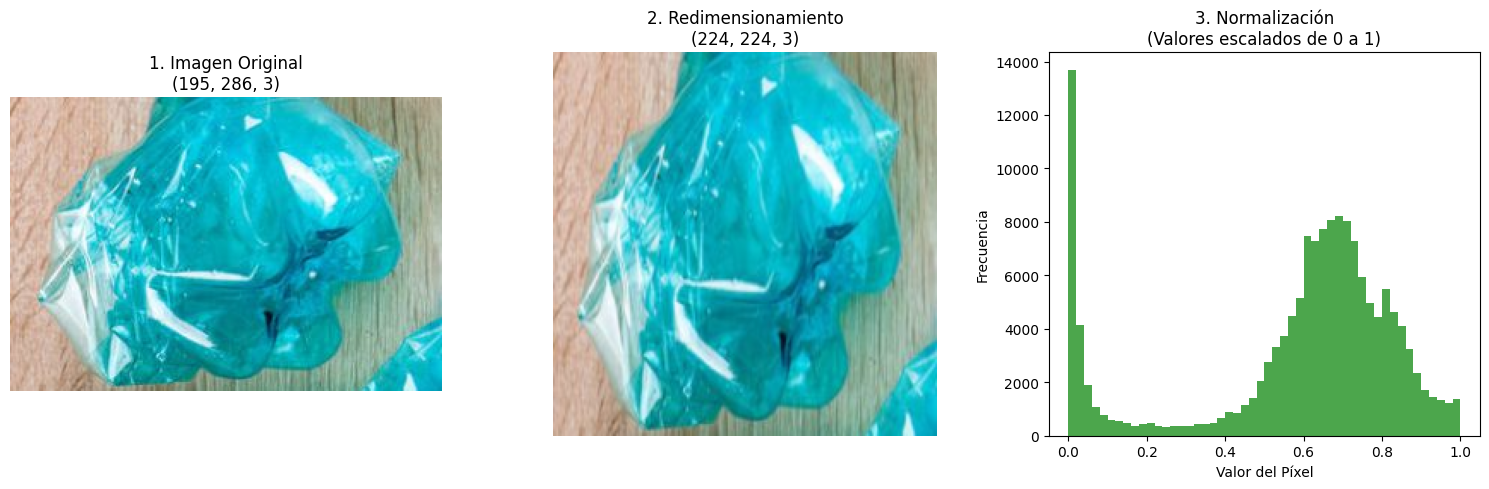

In [19]:
# --- 3. PIPELINE DE VISUALIZACIÓN ---

# Cargar la imagen elegida al azar usando OpenCV
# cv2 lee en BGR, así que lo convertimos a RGB para que Matplotlib lo muestre bien
img_bgr = cv2.imread(str(ruta_imagen_real))
img_color = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 1. Redimensionamiento a lo que espera la red (224x224)
img_resized = cv2.resize(img_color, (224, 224))

# 2. Normalización matemática (dividir entre 255)
img_normalized = img_resized / 255.0

# Graficamos el proceso
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: Original
axes[0].imshow(img_color)
axes[0].set_title(f"1. Imagen Original\n{img_color.shape}")
axes[0].axis('off')

# Panel 2: Resizing
axes[1].imshow(img_resized)
axes[1].set_title(f"2. Redimensionamiento\n{img_resized.shape}")
axes[1].axis('off')

# Panel 3: Normalización (Histograma de colores)
axes[2].hist(img_normalized.ravel(), bins=50, color='green', alpha=0.7)
axes[2].set_title("3. Normalización\n(Valores escalados de 0 a 1)")
axes[2].set_xlabel("Valor del Píxel")
axes[2].set_ylabel("Frecuencia")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "normalizacion_dinamica.png")
plt.show()

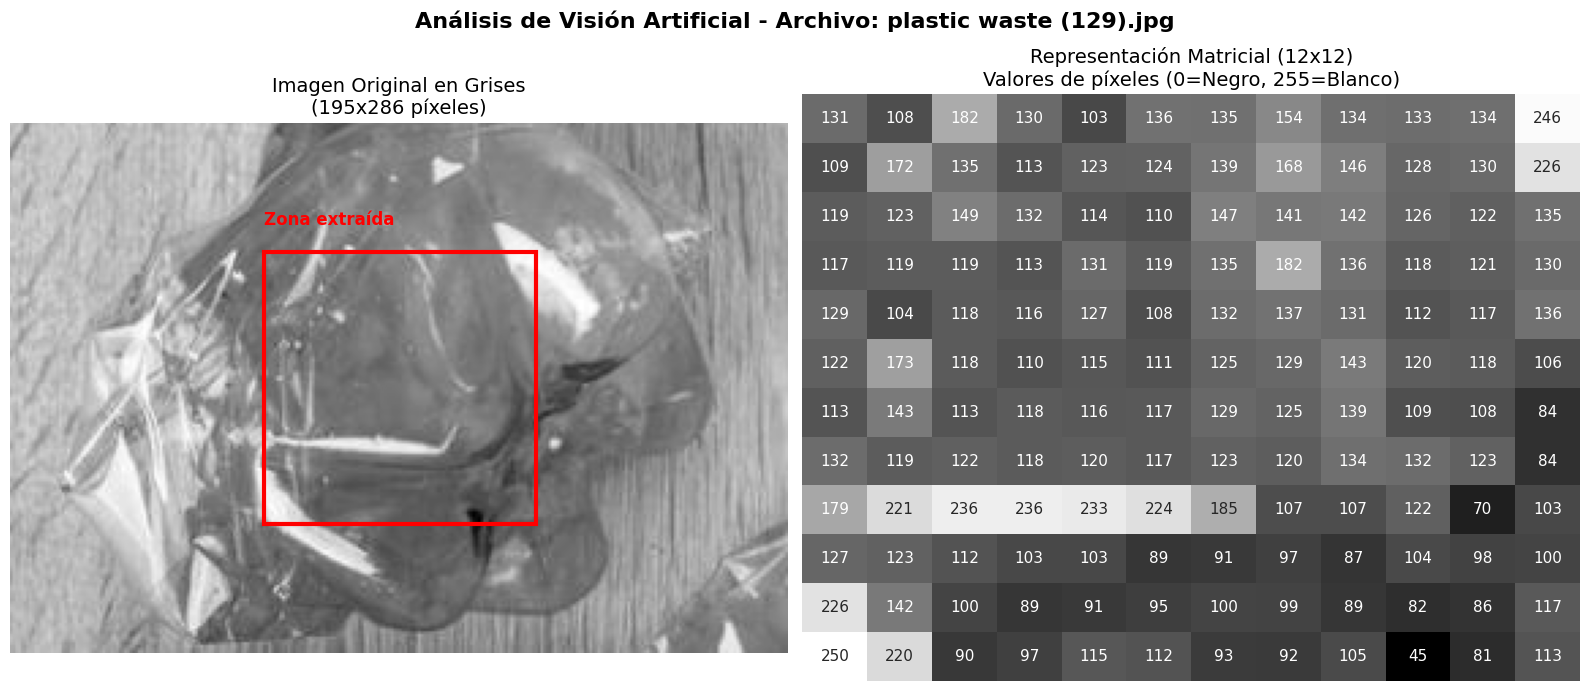

In [20]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# --- 4. REPRESENTACIÓN MATRICIAL (CÓMO VE LA IMAGEN LA COMPUTADORA) ---

# 1. Cargar la imagen dinámica en escala de grises
img_gris = cv2.imread(str(ruta_imagen_real), cv2.IMREAD_GRAYSCALE)

# 2. Calcular el centro y extraer el parche
alto, ancho = img_gris.shape
centro_y, centro_x = alto // 2, ancho // 2

# Coordenadas para un parche de 100x100 en el centro
y1, y2 = centro_y - 50, centro_y + 50
x1, x2 = centro_x - 50, centro_x + 50

# Extraemos el parche y lo redimensionamos a 12x12
parche = img_gris[y1:y2, x1:x2]
recorte_12x12 = cv2.resize(parche, (12, 12))

# 3. Graficar: Imagen Original vs Matriz Numérica
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- PANEL 1: Imagen Original con recuadro ---
axes[0].imshow(img_gris, cmap="gray")
axes[0].set_title(f"Imagen Original en Grises\n({alto}x{ancho} píxeles)", fontsize=14)
axes[0].axis('off')

# Dibujamos un rectángulo rojo indicando la zona del recorte
rect = patches.Rectangle((x1, y1), 100, 100, linewidth=3, edgecolor='red', facecolor='none')
axes[0].add_patch(rect)
axes[0].text(x1, y1 - 10, 'Zona extraída', color='red', fontsize=12, fontweight='bold')

# --- PANEL 2: Representación Matricial ---
sns.heatmap(recorte_12x12, annot=True, fmt="d", cmap="gray", cbar=False, 
            annot_kws={"size": 11}, ax=axes[1])
axes[1].set_title("Representación Matricial (12x12)\nValores de píxeles (0=Negro, 255=Blanco)", fontsize=14)
axes[1].axis('off')

plt.suptitle(f"Análisis de Visión Artificial - Archivo: {ruta_imagen_real.name}", fontsize=16, fontweight='bold')
plt.tight_layout()

# Guardar evidencia
plt.savefig(FIGURES_DIR / "matriz_pixeles_dinamica.png", bbox_inches='tight')
plt.show()

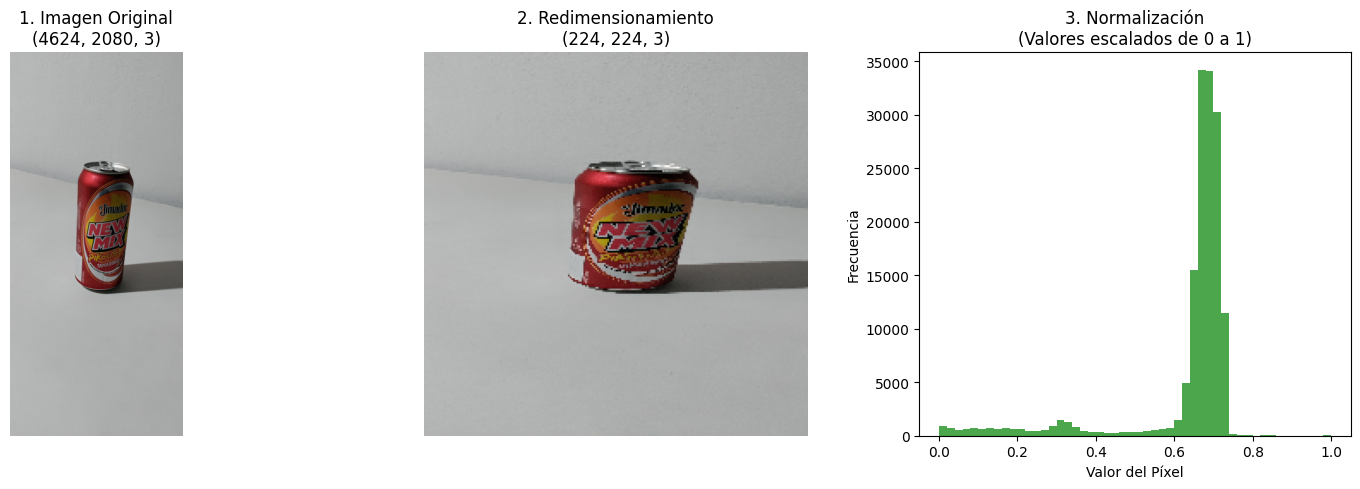

In [14]:
# 1. Imagen Original (A color)
img_color = cv2.imread(IMAGES_TEST_DIR / "aluminio1.jpeg")
img_color = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)

# 2. Resizing (Redimensionamiento a 224x224 para MobileNetV2)
img_resized = cv2.resize(img_color, (224, 224))

# 3. Normalización (Escalado 0 a 1)
img_normalized = img_resized.astype('float32') / 255.0

# Graficar el Pipeline
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: Original
axes[0].imshow(img_color)
axes[0].set_title(f"1. Imagen Original\n{img_color.shape}")
axes[0].axis('off')

# Panel 2: Resizing
axes[1].imshow(img_resized)
axes[1].set_title(f"2. Redimensionamiento\n{img_resized.shape}")
axes[1].axis('off')

# Panel 3: Representación de Normalización (Mostramos un histograma o array)
# Como la imagen normalizada se ve igual, mostraremos la distribución de pixeles
axes[2].hist(img_normalized.ravel(), bins=50, color='green', alpha=0.7)
axes[2].set_title("3. Normalización\n(Valores escalados de 0 a 1)")
axes[2].set_xlabel("Valor del Píxel")
axes[2].set_ylabel("Frecuencia")

plt.tight_layout()
save_path = FIGURES_DIR / "normalizacion_redimensionamiento1.png"
plt.savefig(save_path)
plt.show()